In [71]:
# !pip install geopandas
# !pip install contextily
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import math
import contextily as cx

# Load boundary geography

In [72]:
berk_boundary =gpd.read_file('Data/Berkeley_citylimits.geojson')
berk_boundary = berk_boundary.to_crs(epsg=3857)

oak_boundary =gpd.read_file('Data/OaklandCityLimits/OaklandCityLimits.shp')
oak_boundary = oak_boundary.to_crs(epsg=3857)

combined_boundary = pd.concat([berk_boundary, oak_boundary], ignore_index=True)
# There will still be two distinct polygons between these two polygons, need to dissolve them into one

# Load and clean crash data

## Crash level data

In [73]:
crash_data = pd.read_csv('Data/Oakland_berkeley_crash_SWITRS.csv')

crash_data['COLLISION_DATE_DT'] = pd.to_datetime(crash_data['COLLISION_DATE'])

# Filter for crashes at intersections and after Jan 1, 2023
crash_filtered = crash_data.loc[
                                (crash_data['PEDESTRIAN_ACCIDENT']=='Y') &
                                (crash_data['COLLISION_DATE']>'2023-01-01')&
                                # (ped_crashes['INTERSECTION']=='Y')&
                                (crash_data['DISTANCE']<=10) #Distance less than or equal to 10 ft from intersection
                                ]
# Check date
print(crash_filtered['COLLISION_DATE'].min())
print(crash_filtered['COLLISION_DATE'].max())

# Check shape
print(crash_filtered.shape)

# Convert crash data to gdf
crash_gdf = gpd.GeoDataFrame(
    crash_filtered, 
    geometry=gpd.points_from_xy(crash_filtered['POINT_X'], crash_filtered['POINT_Y'], 
    crs = 4326)
    )

# Clip crash gdf by geography boundary
if crash_gdf.crs != combined_boundary.crs:
    crash_gdf = crash_gdf.to_crs(combined_boundary.crs)

# Perform the clipping operation
crash_clipped = gpd.clip(crash_gdf, combined_boundary)
crash_clipped

2023-01-03
2025-09-28
(616, 81)


,CASE_ID,ACCIDENT_YEAR,PROC_DATE,JURIS,COLLISION_DATE,COLLISION_TIME,OFFICER_ID,REPORTING_DISTRICT,DAY_OF_WEEK,CHP_SHIFT,POPULATION,CNTY_CITY_LOC,SPECIAL_COND,BEAT_TYPE,CHP_BEAT_TYPE,CITY_DIVISION_LAPD,CHP_BEAT_CLASS,BEAT_NUMBER,PRIMARY_RD,SECONDARY_RD,DISTANCE,DIRECTION,INTERSECTION,WEATHER_1,WEATHER_2,STATE_HWY_IND,CALTRANS_COUNTY,CALTRANS_DISTRICT,STATE_ROUTE,ROUTE_SUFFIX,POSTMILE_PREFIX,POSTMILE,LOCATION_TYPE,RAMP_INTERSECTION,SIDE_OF_HWY,TOW_AWAY,COLLISION_SEVERITY,NUMBER_KILLED,NUMBER_INJURED,PARTY_COUNT,PRIMARY_COLL_FACTOR,PCF_CODE_OF_VIOL,PCF_VIOL_CATEGORY,PCF_VIOLATION,PCF_VIOL_SUBSECTION,HIT_AND_RUN,TYPE_OF_COLLISION,MVIW,PED_ACTION,ROAD_SURFACE,ROAD_COND_1,ROAD_COND_2,LIGHTING,CONTROL_DEVICE,CHP_ROAD_TYPE,PEDESTRIAN_ACCIDENT,BICYCLE_ACCIDENT,MOTORCYCLE_ACCIDENT,TRUCK_ACCIDENT,NOT_PRIVATE_PROPERTY,ALCOHOL_INVOLVED,STWD_VEHTYPE_AT_FAULT,CHP_VEHTYPE_AT_FAULT,COUNT_SEVERE_INJ,COUNT_VISIBLE_INJ,COUNT_COMPLAINT_PAIN,COUNT_PED_KILLED,COUNT_PED_INJURED,COUNT_BICYCLIST_KILLED,COUNT_BICYCLIST_INJURED,COUNT_MC_KILLED,COUNT_MC_INJURED,PRIMARY_RAMP,SECONDARY_RAMP,LATITUDE,LONGITUDE,COUNTY,CITY,POINT_X,POINT_Y,COLLISION_DATE_DT,geometry
17796,9756578,2024,2024-11-27,109,2024-07-30,1230,9242,2,2,5,7,109,0,0,0,NaN,0,31X,98TH AV,RT 880,0.0,NaN,Y,B,-,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,4,0,1,2,A,-,10,21950.0,A,N,G,B,B,A,H,-,A,A,0,Y,NaN,NaN,NaN,Y,NaN,A,07,0,0,1,0,1,0,0,0,0,-,NF,NaN,NaN,ALAMEDA,OAKLAND,-122.188652,37.731590,2024-07-30,POINT (-13601978.526 4541577.603)
10635,9625457,2023,2023-10-03,109,2023-06-05,1533,9919,2,1,5,7,109,0,0,0,NaN,0,31X,EDES AV,98TH AV,0.0,NaN,Y,A,-,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,4,0,1,2,A,-,03,22350.0,NaN,M,G,B,B,A,H,-,A,A,0,Y,NaN,NaN,Y,Y,NaN,F,26,0,0,1,0,1,0,0,0,0,-,-,NaN,NaN,ALAMEDA,OAKLAND,-122.183311,37.736431,2023-06-05,POINT (-13601384.015 4542258.988)
5185,9650223,2023,2024-01-22,109,2023-04-28,2340,10063,2,5,5,7,109,0,0,0,NaN,0,31Y,98TH AV,EDES AV,0.0,NaN,Y,A,-,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,3,0,1,2,A,-,10,21950.0,A,N,G,B,B,A,H,-,C,A,0,Y,NaN,NaN,NaN,Y,NaN,D,22,0,1,0,0,1,0,0,0,0,-,-,NaN,NaN,ALAMEDA,OAKLAND,-122.183311,37.736431,2023-04-28,POINT (-13601384.015 4542258.988)
5436,9806914,2025,2025-05-16,109,2025-03-23,1244,10027,2,7,5,7,109,0,0,0,NaN,0,31Y,98TH AV,EDES AV,0.0,NaN,Y,A,-,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,3,0,1,2,A,-,11,21453.0,D,N,G,B,B,A,H,-,A,A,0,Y,NaN,NaN,NaN,Y,NaN,N,60,0,1,0,0,1,0,0,0,0,-,-,NaN,NaN,ALAMEDA,OAKLAND,-122.183311,37.736431,2025-03-23,POINT (-13601384.015 4542258.988)
24937,9885390,2025,2025-11-05,109,2025-08-06,927,9736,2,3,5,7,109,0,0,0,NaN,0,31Z,STONE ST,PIPPIN ST,5.0,S,N,A,-,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,4,0,1,4,A,-,05,21651.0,A,M,G,B,E,A,H,-,A,D,0,Y,NaN,NaN,NaN,Y,NaN,-,99,0,0,1,0,1,0,0,0,0,-,-,NaN,NaN,ALAMEDA,OAKLAND,-122.177910,37.736702,2025-08-06,POINT (-13600782.711 4542297.113)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24646,9774271,2025,2025-02-11,109,2025-01-02,716,9490,1,4,5,7,109,0,0,0,NaN,0,13X,LA SALLE AV,MORAGA AV,0.0,NaN,Y,A,-,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,3,0,1,2,A,-,10,21950.0,A,N,G,B,B,A,H,-,A,A,0,Y,NaN,NaN,NaN,Y,NaN,D,82,0,1,0,0,1,0,0,0,0,-,-,NaN,NaN,ALAMEDA,OAKLAND,-122.210556,37.826199,2025-01-02,POINT (-13604416.867 4554902.511)
17540,9685755,2024,2024-06-19,109,2024-03-19,1145,9951,1,2,5,7,109,0,0,0,NaN,0,13Z,LA SALLE AVE,MOUNTAIN BLVD,0.0,NaN,Y,A,-,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,2,0,1,2,A,-,10,21950.0,A,N,G,B,B,A,H,-,A,A,0,Y,NaN,NaN,NaN,Y,NaN,I,12,1,0,0,0,1,0,0,0,0,-,-,NaN,NaN,ALAMEDA,OAKLAND,-122.209557,37.826729,2024-03-19,POINT (-13604305.609 4554977.241)
33849,9892055,2025,2025-12-01,109,2025-09-06,1355,10042,1,6,5,7,109,0,0,0,NaN,0,13X,MORAGA AV,MEDAU PL,0.0,NaN,Y,A,-,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

## Party level data

In [74]:
print('Size of cleaned crashes df:', crash_clipped.shape)

# Load crash party data
parties = pd.read_csv('Data/Oakland_berkeley_crash_parties_after2023_SWITRS.csv', low_memory=False)
print('Size of parties df:', parties.shape)

# Filter so only parties are pedestrians
parties_ped_only = parties.loc[parties['PARTY_TYPE']=='2']

# Merge on CASE_ID
crashes_parties = pd.merge(crash_clipped, parties_ped_only, on='CASE_ID', how='left')
display(crashes_parties)

# Check date range
print(crashes_parties['COLLISION_DATE'].min())
print(crashes_parties['COLLISION_DATE'].max())

Size of cleaned crashes df: (609, 82)
Size of parties df: (15669, 34)


,CASE_ID,ACCIDENT_YEAR_x,PROC_DATE,JURIS,COLLISION_DATE,COLLISION_TIME,OFFICER_ID,REPORTING_DISTRICT,DAY_OF_WEEK,CHP_SHIFT,POPULATION,CNTY_CITY_LOC,SPECIAL_COND,BEAT_TYPE,CHP_BEAT_TYPE,CITY_DIVISION_LAPD,CHP_BEAT_CLASS,BEAT_NUMBER,PRIMARY_RD,SECONDARY_RD,DISTANCE,DIRECTION,INTERSECTION,WEATHER_1,WEATHER_2,STATE_HWY_IND,CALTRANS_COUNTY,CALTRANS_DISTRICT,STATE_ROUTE,ROUTE_SUFFIX,POSTMILE_PREFIX,POSTMILE,LOCATION_TYPE,RAMP_INTERSECTION,SIDE_OF_HWY,TOW_AWAY,COLLISION_SEVERITY,NUMBER_KILLED,NUMBER_INJURED,PARTY_COUNT,PRIMARY_COLL_FACTOR,PCF_CODE_OF_VIOL,PCF_VIOL_CATEGORY,PCF_VIOLATION,PCF_VIOL_SUBSECTION,HIT_AND_RUN,TYPE_OF_COLLISION,MVIW,PED_ACTION,ROAD_SURFACE,ROAD_COND_1,ROAD_COND_2,LIGHTING,CONTROL_DEVICE,CHP_ROAD_TYPE,PEDESTRIAN_ACCIDENT,BICYCLE_ACCIDENT,MOTORCYCLE_ACCIDENT,TRUCK_ACCIDENT,NOT_PRIVATE_PROPERTY,ALCOHOL_INVOLVED,STWD_VEHTYPE_AT_FAULT,CHP_VEHTYPE_AT_FAULT,COUNT_SEVERE_INJ,COUNT_VISIBLE_INJ,COUNT_COMPLAINT_PAIN,COUNT_PED_KILLED,COUNT_PED_INJURED,COUNT_BICYCLIST_KILLED,COUNT_BICYCLIST_INJURED,COUNT_MC_KILLED,COUNT_MC_INJURED,PRIMARY_RAMP,SECONDARY_RAMP,LATITUDE,LONGITUDE,COUNTY,CITY,POINT_X,POINT_Y,COLLISION_DATE_DT,geometry,PARTY_NUMBER,PARTY_TYPE,AT_FAULT,PARTY_SEX,PARTY_AGE,PARTY_SOBRIETY,PARTY_DRUG_PHYSICAL,DIR_OF_TRAVEL,PARTY_SAFETY_EQUIP_1,PARTY_SAFETY_EQUIP_2,FINAN_RESPONS,SP_INFO_1,SP_INFO_2,SP_INFO_3,OAF_VIOLATION_CODE,OAF_VIOL_CAT,OAF_VIOL_SECTION,OAF_VIOLATION_SUFFIX,OAF_1,OAF_2,PARTY_NUMBER_KILLED,PARTY_NUMBER_INJURED,MOVE_PRE_ACC,VEHICLE_YEAR,VEHICLE_MAKE,STWD_VEHICLE_TYPE,CHP_VEH_TYPE_TOWING,CHP_VEH_TYPE_TOWED,RACE,INATTENTION,SPECIAL_INFO_F,SPECIAL_INFO_G,ACCIDENT_YEAR_y
0,9756578,2024,2024-11-27,109,2024-07-30,1230,9242,2,2,5,7,109,0,0,0,NaN,0,31X,98TH AV,RT 880,0.0,NaN,Y,B,-,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,4,0,1,2,A,-,10,21950.0,A,N,G,B,B,A,H,-,A,A,0,Y,NaN,NaN,NaN,Y,NaN,A,07,0,0,1,0,1,0,0,0,0,-,NF,NaN,NaN,ALAMEDA,OAKLAND,-122.188652,37.731590,2024-07-30,POINT (-13601978.526 4541577.603),2,2,N,M,60,A,-,N,-,-,O,-,-,-,-,-,NaN,NaN,-,-,0,1,B,NaN,-,N,60.0,NaN,W,NaN,-,-,2024
1,9625457,2023,2023-10-03,109,2023-06-05,1533,9919,2,1,5,7,109,0,0,0,NaN,0,31X,EDES AV,98TH AV,0.0,NaN,Y,A,-,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,4,0,1,2,A,-,03,22350.0,NaN,M,G,B,B,A,H,-,A,A,0,Y,NaN,NaN,Y,Y,NaN,F,26,0,0,1,0,1,0,0,0,0,-,-,NaN,NaN,ALAMEDA,OAKLAND,-122.183311,37.736431,2023-06-05,POINT (-13601384.015 4542258.988),2,2,N,M,57,A,-,W,-,-,O,-,-,-,-,-,NaN,NaN,N,-,0,1,-,NaN,-,N,60.0,NaN,B,NaN,-,-,2023
2,9650223,2023,2024-01-22,109,2023-04-28,2340,10063,2,5,5,7,109,0,0,0,NaN,0,31Y,98TH AV,EDES AV,0.0,NaN,Y,A,-,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,3,0,1,2,A,-,10,21950.0,A,N,G,B,B,A,H,-,C,A,0,Y,NaN,NaN,NaN,Y,NaN,D,22,0,1,0,0,1,0,0,0,0,-,-,NaN,NaN,ALAMEDA,OAKLAND,-122.183311,37.736431,2023-04-28,POINT (-13601384.015 4542258.988),2,2,N,F,30,A,-,S,-,-,O,-,3,-,-,-,NaN,NaN,N,-,0,1,-,NaN,-,N,60.0,NaN,H,NaN,-,-,2023
3,9806914,2025,2025-05-16,109,2025-03-23,1244,10027,2,7,5,7,109,0,0,0,NaN,0,31Y,98TH AV,EDES AV,0.0,NaN,Y,A,-,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,3,0,1,2,A,-,11,21453.0,D,N,G,B,B,A,H,-,A,A,0,Y,NaN,NaN,NaN,Y,NaN,N,60,0,1,0,0,1,0,0,0,0,-,-,NaN,NaN,ALAMEDA,OAKLAND,-122.183311,37.736431,2025-03-23,POINT (-13601384.015 4542258.988),1,2,Y,F,13,G,G,N,-,-,O,-,-,-,-,-,NaN,NaN,N,-,0,1,-,NaN,-,N,60.0,NaN,H,NaN,-,-,2025
4,9885390,2025,2025-11-05,109,2025-08-06,927,9736,2,3,5,7,109,0,0,0,NaN,0,31Z,STONE ST,PIPPIN ST,5.0,S,N,A,-,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,4,0,1,4,A,-,05,21651.0,A,M,G,B,E,A,H,-,A,D,0,Y,NaN,NaN,NaN,Y,NaN,-,99,0,0,1,0,1,0,0,0,0,-,-,NaN,NaN,ALAMEDA,OAKLAND,-122.177910,37.736702,2025-08-06,POINT (-13600782.711 4542297.113),2,2,N,F,23,A,-,-,-,-,O,-,-,-,-,-,NaN,NaN,N,-,0,1,-,NaN,-,N,60.0,NaN,B,NaN,-,-,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

2023-01-03
2025-09-28


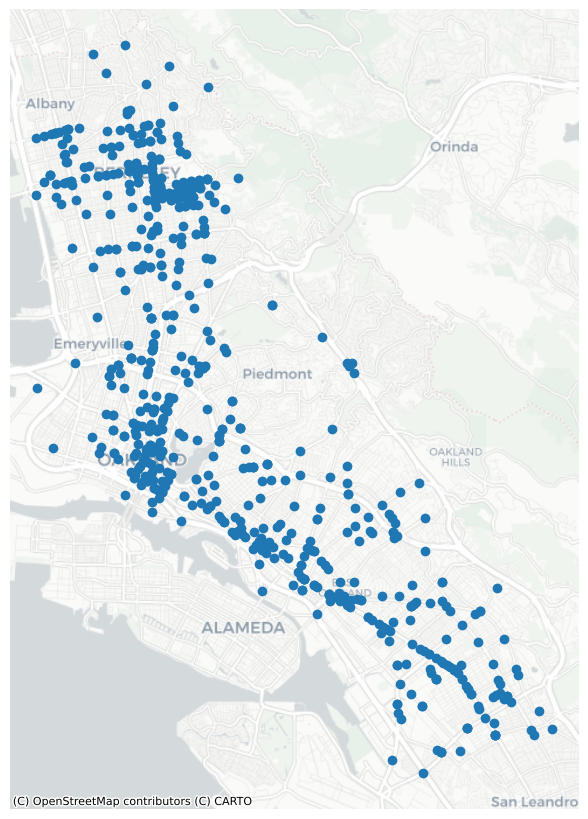

In [75]:
fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
crashes_parties.plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
# LT - 4/14 - Idk why the base map isn't working for this one map
ax.set_axis_off()

In [76]:
# Select columns from the dataframe
crashes_parties = crashes_parties[[
    'CASE_ID',
    'COLLISION_DATE_DT',
    'COLLISION_SEVERITY',
    'CITY',
    'POINT_X',
    'POINT_Y',
    'geometry',
    'AT_FAULT',
    'PARTY_SEX',
    'PARTY_AGE',
    'RACE',
    'LIGHTING',
    'DAY_OF_WEEK',
    'WEATHER_1',
    'PRIMARY_COLL_FACTOR',
    'PED_ACTION',
    'PARTY_NUMBER_KILLED',
    'PARTY_NUMBER_INJURED',
]]

crashes_parties.shape

(637, 18)

# Process data function (only works for signals and islands)

In [ ]:
# Write function to load in data, clip it by its respective boundary and then combine the Oakland and Berkeley data
def process_data(berk_data_name, oak_data_name):

    # Load data
    berk_data = gpd.read_file('Data/'+berk_data_name)
    berk_data = berk_data.to_crs(epsg=3857)

    oak_data = gpd.read_file('Data/'+oak_data_name)
    oak_data = oak_data.to_crs(epsg=3857)

    # Adjust the CRS
    for data in [berk_data, oak_data]:
        if data.crs != combined_boundary.crs:
            data = data.to_crs(combined_boundary.crs)

    # Combine dataframes
    combined_data = pd.concat([berk_data, oak_data])

    # Perform the clipping operation
    return gpd.clip(combined_data, combined_boundary)

# Load and clean signal data data

,id,@id,button_operated,cycleway,fixme,highway,note,traffic_calming,traffic_signals,traffic_signals:colour,traffic_signals:direction,traffic_signals:sound,geometry,bus,crossing,direction,disused:railway,name,network,public_transport,restriction,start_date,traffic_signals:countdown
489,node/10742735831,node/10742735831,None,NaN,NaN,traffic_signals,None,NaN,traffic_lights,NaN,forward,None,POINT (-13603852.251 4539579.713),None,None,None,None,None,None,None,None,None,None
488,node/10742735828,node/10742735828,None,NaN,NaN,traffic_signals,None,NaN,traffic_lights,NaN,forward,None,POINT (-13603848.811 4539594.264),None,None,None,None,None,None,None,None,None,None
270,node/679007076,node/679007076,None,NaN,NaN,traffic_signals,None,NaN,traffic_lights,NaN,forward,None,POINT (-13603842.065 4539606.423),None,None,None,None,None,None,None,None,None,None
209,node/241855910,node/241855910,None,NaN,NaN,traffic_signals,None,NaN,None,NaN,backward,None,POINT (-13603890.823 4539646.08),None,None,None,None,None,None,None,None,None,None
362,node/3149810914,node/3149810914,None,NaN,NaN,traffic_signals,None,NaN,None,NaN,None,None,POINT (-13603848.388 4539651.709),None,None,None,None,None,None,None,None,None,None


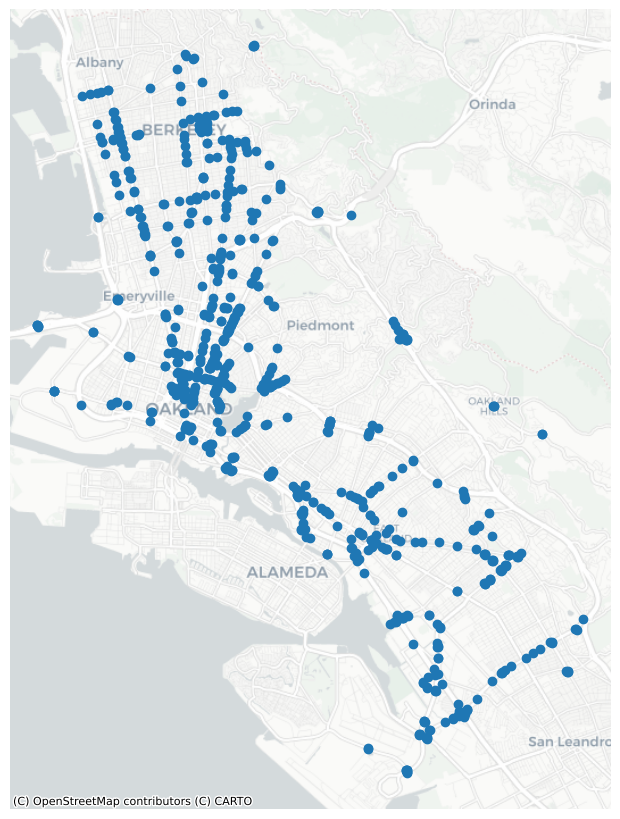

In [78]:
signal_data = process_data("Berkeley_trafficsignal_after2023_osm.geojson", 
                           "Oakland_trafficsignal_after2023.geojson"
                           )
display(signal_data.head())
# LT - Apr14 - This looks weird because the data sources are diff so the columns don't match... does it still work though?

fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
signal_data.plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

# Load and clean traffic island data 

,id,@id,bicycle,foot,footway,highway,lit,motor_vehicle,surface,tactile_paving,geometry,button_operated,crossing:island,informal
161,way/1449967049,way/1449967049,None,None,traffic_island,footway,None,NaN,None,None,"LINESTRING (-13603445.868 4540896.624, -136034...",None,None,None
160,way/1449967046,way/1449967046,None,None,traffic_island,footway,None,NaN,None,None,"LINESTRING (-13603448.941 4540900.537, -136034...",None,None,None
162,way/1449967053,way/1449967053,None,None,traffic_island,footway,None,NaN,None,None,"LINESTRING (-13603264.172 4541250.896, -136032...",None,None,None
163,way/1449967058,way/1449967058,None,None,traffic_island,footway,None,NaN,None,None,"LINESTRING (-13603261.957 4541257.807, -136032...",None,None,None
164,way/1449967061,way/1449967061,None,None,traffic_island,footway,None,NaN,None,None,"LINESTRING (-13603254.321 4541271.558, -136032...",None,None,None


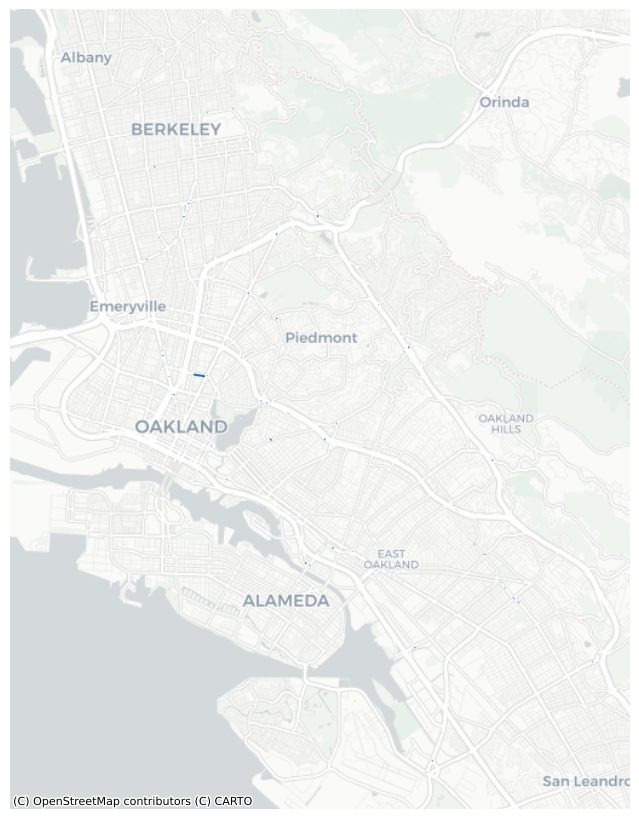

In [79]:
island_data = process_data("Berkeley_islands_after2023.geojson", 
                           "Oakland_islands_after2023.geojson"
                           )
display(island_data.head())

fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
island_data.plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

# Load and clean volume data

,networkLinkId,trip_count,roadName,direction,startLat,startLon,endLat,endLon,highway,distance,osmId,geometry
42421,15425380419639251921,416,Airport Drive,East,37.711557,-122.211016,37.711580,-122.210846,trunk,0.009321,309646685,"LINESTRING (-13604468.07 4538758.244, -1360444..."
80979,8169027530609871353,73,None,East,37.711605,-122.210998,37.711580,-122.210846,service,0.008699,96843947,"LINESTRING (-13604466.067 4538764.998, -136044..."
37238,6238437508025344035,542,Airport Drive,East,37.711673,-122.211579,37.711557,-122.211016,trunk,0.031690,309646685,"LINESTRING (-13604530.743 4538774.567, -136045..."
39133,12991988566429086493,490,Airport Drive,East,37.711580,-122.210846,37.711695,-122.210312,trunk,0.030447,309646685,"LINESTRING (-13604449.035 4538761.48, -1360440..."
45833,766424847014960647,356,Airport Drive,SouthEast,37.711703,-122.211632,37.711673,-122.211579,trunk,0.003728,238036776,"LINESTRING (-13604536.643 4538778.788, -136045..."


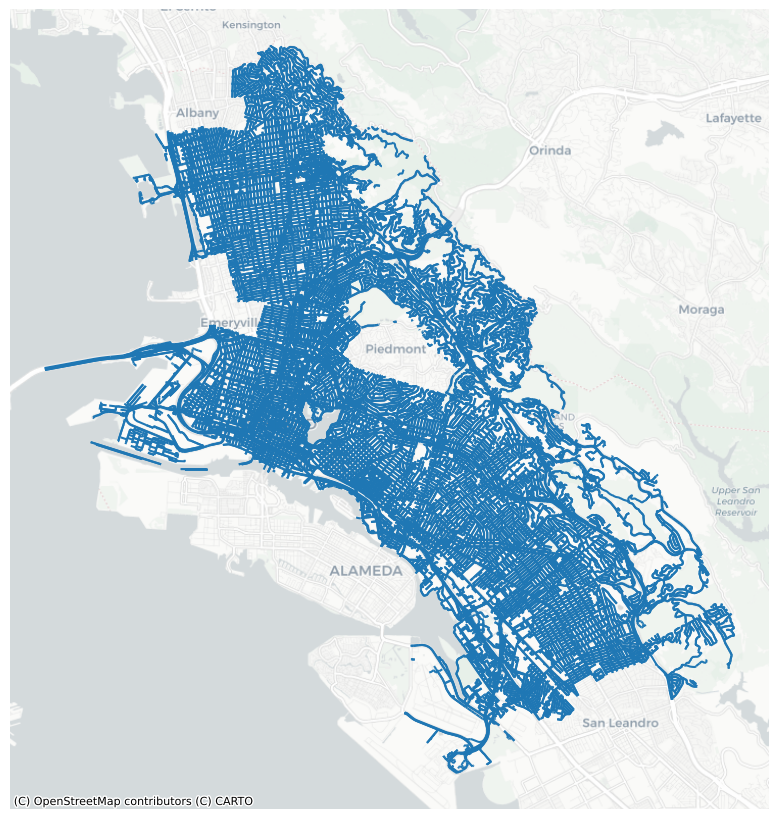

In [80]:
volume_data = gpd.read_file('Data/replica-traffic_islands_study-04_02_26-network_link_layer/replica-traffic_islands_study-04_02_26-network_link_layer.geojson')
volume_data = volume_data.to_crs(epsg=3857)

if volume_data.crs != combined_boundary.crs:
    volume_data = volume_data.to_crs(combined_boundary.crs)

# Clip data
volume_data = gpd.clip(volume_data, combined_boundary)

display(volume_data.head())

fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
volume_data.plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()


# Load and clean functional classification data
**This is incomplete**

# Add signal, island, and volume data to crash dataframe

## Associate islands with crashes using a buffer

In [91]:
# Create 30 ft buffer around each traffic island
island_data['buffer'] = island_data['geometry'].buffer(30)

# Set as the new geometry of the dataframe
island_data = island_data.set_geometry(island_data['buffer'])

**LT - I'm not sure if this is the right type of spatial join**

crashes_parties shape:  (637, 19)
island_data shape:  (237, 15)


,index_left,CASE_ID,COLLISION_DATE_DT,COLLISION_SEVERITY,CITY,POINT_X,POINT_Y,AT_FAULT,PARTY_SEX,PARTY_AGE,RACE,LIGHTING,DAY_OF_WEEK,WEATHER_1,PRIMARY_COLL_FACTOR,PED_ACTION,PARTY_NUMBER_KILLED,PARTY_NUMBER_INJURED,AT_TRAFFIC_ISLAND,id,@id,bicycle,foot,footway,highway,lit,motor_vehicle,surface,tactile_paving,geometry,button_operated,crossing:island,informal,buffer
161,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,way/1449967049,way/1449967049,None,None,traffic_island,footway,None,NaN,None,None,"LINESTRING (-13603445.868 4540896.624, -136034...",None,None,None,"POLYGON ((-13603416.838 4540887.943, -13603417..."
160,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,way/1449967046,way/1449967046,None,None,traffic_island,footway,None,NaN,None,None,"LINESTRING (-13603448.941 4540900.537, -136034...",None,None,None,"POLYGON ((-13603422.285 4540915.168, -13603419..."
162,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,way/1449967053,way/1449967053,None,None,traffic_island,footway,None,NaN,None,None,"LINESTRING (-13603264.172 4541250.896, -136032...",None,None,None,"POLYGON ((-13603293.727 4541255.834, -13603293..."
163,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,way/1449967058,way/1449967058,None,None,traffic_island,footway,None,NaN,None,None,"LINESTRING (-13603261.957 4541257.807, -136032...",None,None,None,"POLYGON ((-13603282.056 4541280.319, -13603279..."
164,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,way/1449967061,way/1449967061,None,None,traffic_island,footway,None,NaN,None,None,"LINESTRING (-13603254.321 4541271.558, -136032...",None,None,None,"POLYGON ((-13603279.261 4541288.916, -13603277..."


New dataframe shape: (267, 34)


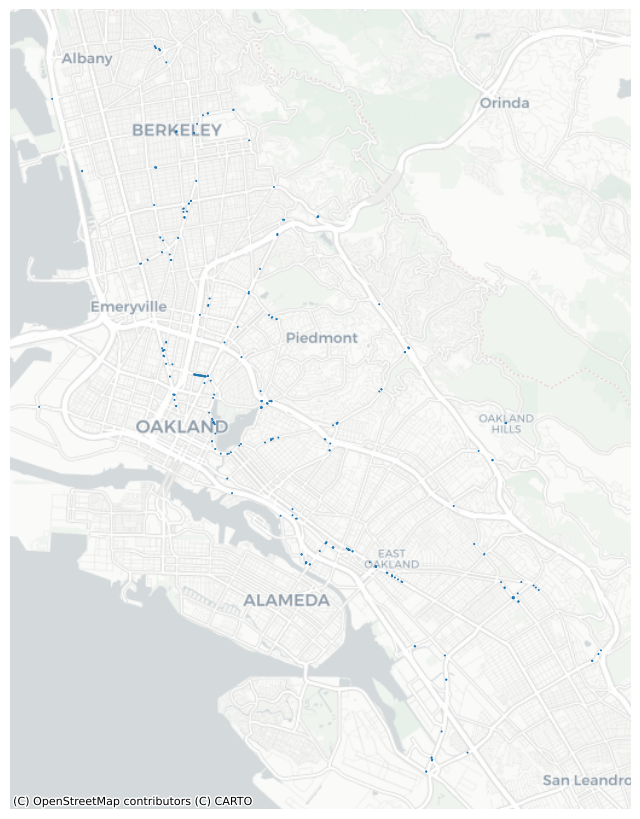

In [111]:
island_data = island_data.to_crs(crashes_parties.crs)

print('crashes_parties shape: ', crashes_parties.shape)
print('island_data shape: ', island_data.shape)

# Spatial join: keeps points within polygon, adds polygon attributes
island_with_crashes = gpd.sjoin(crashes_parties, island_data, how="right", 
                        #    predicate='within'
                           )
display(island_with_crashes.head())
print('New dataframe shape:', island_with_crashes.shape)

fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
island_with_crashes.plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

**LT - Why is the count so low? I thought there were more than 36 crashes that took place at islands? According to the last cell, it should be more like 64**

In [112]:
# Add a column to crashes_parties that indicates whether the crash took place at an island
island_cases = island_with_crashes['CASE_ID'].unique()
crashes_parties['AT_TRAFFIC_ISLAND'] = crashes_parties['CASE_ID'].isin(island_cases)
crashes_parties['AT_TRAFFIC_ISLAND'].value_counts()

AT_TRAFFIC_ISLAND
False    601
True      36
Name: count, dtype: int64